Using device: cpu
===== Federated Training =====

----- Round 1/5 -----
Client 0 training:
  Local epoch 1/5, Train loss: 0.2667, Val loss: 0.1841
  Local epoch 2/5, Train loss: 0.1085, Val loss: 0.0762
  Local epoch 3/5, Train loss: 0.0395, Val loss: 0.0193
  Local epoch 4/5, Train loss: 0.0344, Val loss: 0.0188
  Local epoch 5/5, Train loss: 0.0309, Val loss: 0.0343
Client 1 training:
  Local epoch 1/5, Train loss: 0.1921, Val loss: 0.0140
  Local epoch 2/5, Train loss: 0.0248, Val loss: 0.0478
  Local epoch 3/5, Train loss: 0.0278, Val loss: 0.0177
  Local epoch 4/5, Train loss: 0.0145, Val loss: 0.0126
  Local epoch 5/5, Train loss: 0.0081, Val loss: 0.0276
Client 2 training:
  Local epoch 1/5, Train loss: 0.0832, Val loss: 0.0224
  Local epoch 2/5, Train loss: 0.0141, Val loss: 0.0170
  Local epoch 3/5, Train loss: 0.0095, Val loss: 0.0189
  Local epoch 4/5, Train loss: 0.0059, Val loss: 0.0188
  Local epoch 5/5, Train loss: 0.0057, Val loss: 0.0168
Round average federated loss: 0

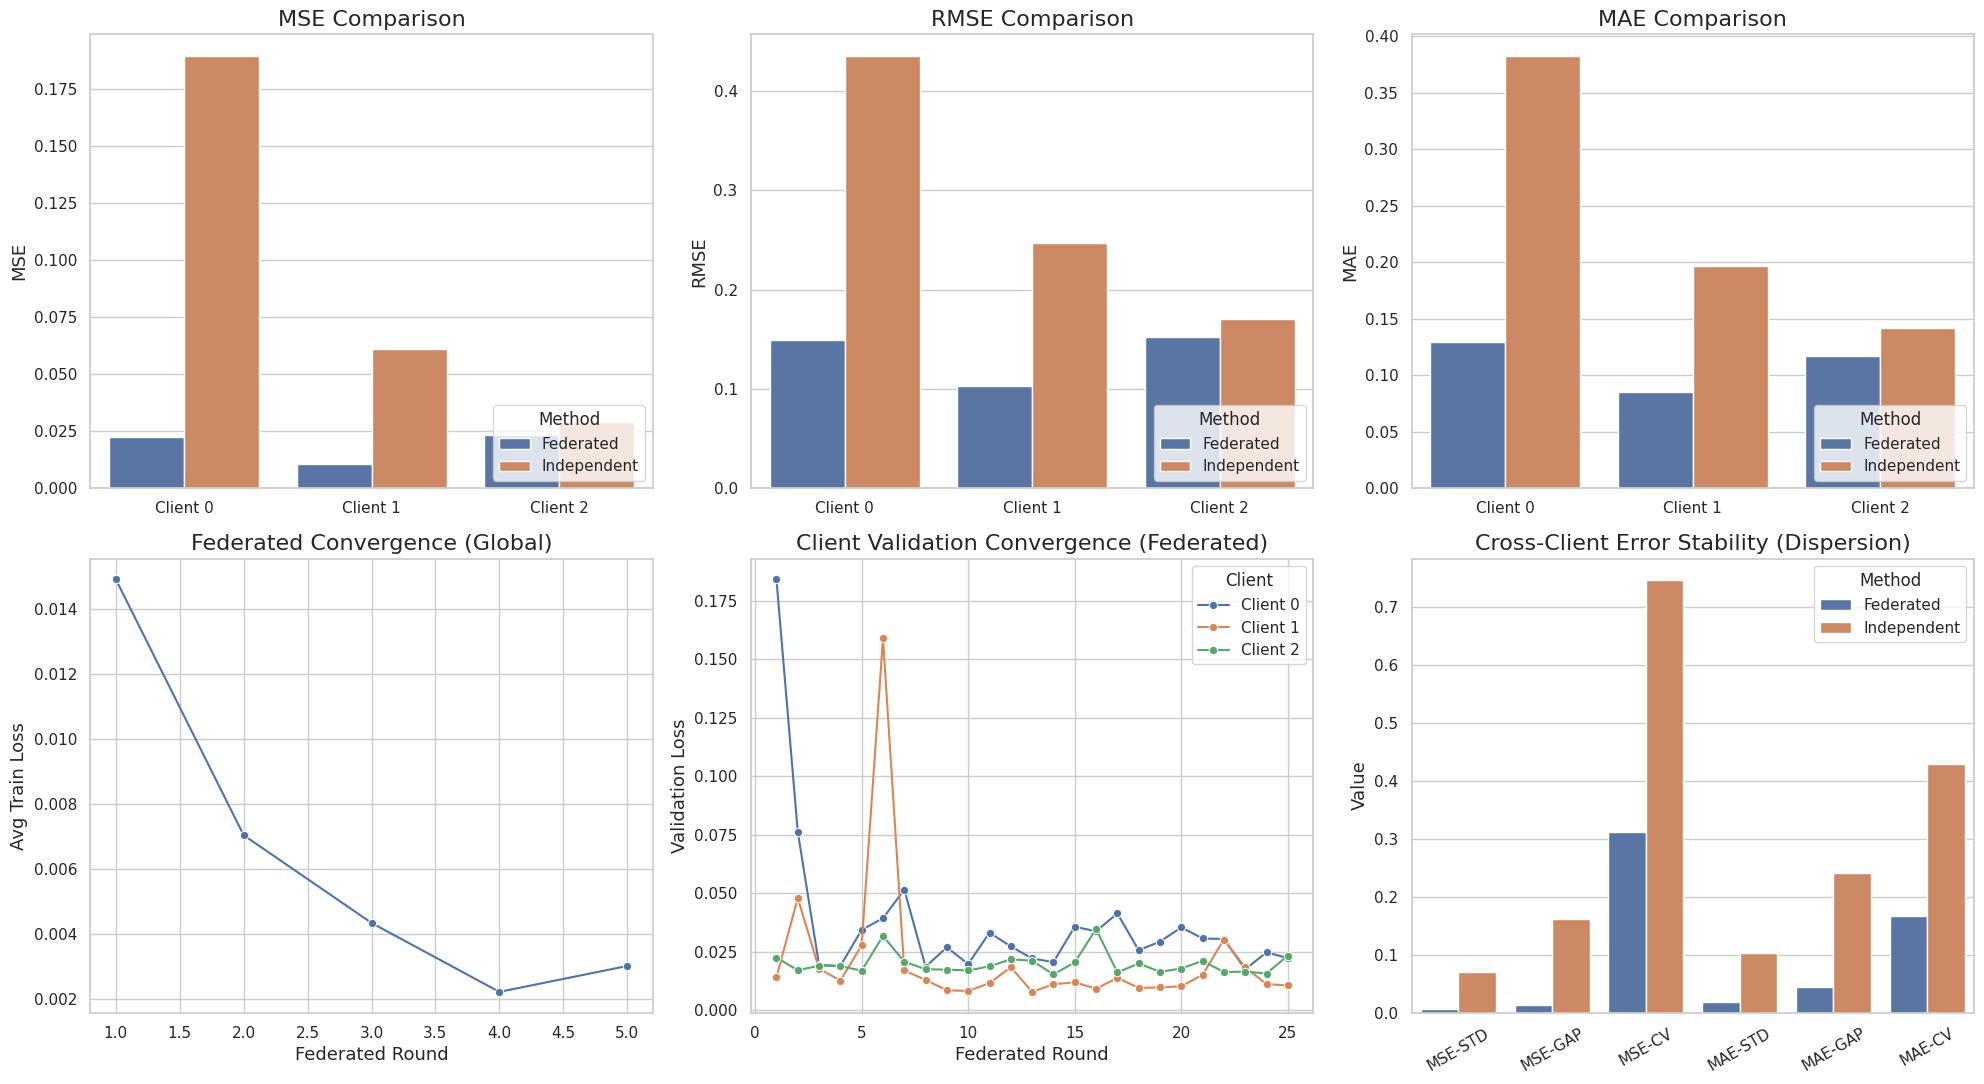

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# Reproducibility: seed = 48
# =========================
SEED = 48
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Visualization style (English + reasonable font sizes)
# =========================
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# GCN Layer
# =========================
class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)

    def forward(self, X, A_norm):
        # X: [B, K, F], A_norm: [K, K]
        # 传播：A_norm @ X
        AX = torch.einsum("ij,bjf->bif", A_norm, X)
        return self.lin(AX)

class GCNEncoder(nn.Module):
    def __init__(self, K, T, hidden_dim=128):
        super().__init__()
        self.K = K
        self.T = T
        self.hidden_dim = hidden_dim

        # 把每个节点的时间序列（长度 T）映射到 hidden_dim
        self.node_proj = nn.Sequential(
            nn.Linear(T, hidden_dim),
            nn.LayerNorm(hidden_dim),
            AdaptiveSwish(),
        )

        self.gcn1 = SimpleGCNLayer(hidden_dim, hidden_dim)
        self.gcn2 = SimpleGCNLayer(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act = AdaptiveSwish()

        # 可学习邻接（KxK），训练时自动学“变量间关系”
        self.A_param = nn.Parameter(torch.randn(K, K) * 0.01)

    def _normalize_adj(self, A):
        # A: [K, K]
        # 让邻接非负、加自环、做对称归一化：D^{-1/2} A D^{-1/2}
        A = torch.relu(A)
        I = torch.eye(self.K, device=A.device, dtype=A.dtype)
        A = A + I
        deg = A.sum(dim=1)  # [K]
        deg_inv_sqrt = torch.pow(deg + 1e-12, -0.5)
        D_inv_sqrt = torch.diag(deg_inv_sqrt)
        return D_inv_sqrt @ A @ D_inv_sqrt  # [K, K]

    def forward(self, x):
        # x: [B, K, T]
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape

        # 每个节点：T -> hidden
        X = self.node_proj(x)  # [B, K, hidden]

        A_norm = self._normalize_adj(self.A_param)

        H = self.gcn1(X, A_norm)
        H = self.norm1(H)
        H = self.act(H)

        H = self.gcn2(H, A_norm)
        H = self.norm2(H)
        H = self.act(H)

        # 图级 pooling：对节点取平均 -> [B, hidden]
        g = H.mean(dim=1)
        return g

# =========================
# Adaptive Activation
# =========================
class AdaptiveSwish(nn.Module):
    def __init__(self, trainable=True):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1, dtype=torch.float32)) if trainable else torch.tensor(1.0, dtype=torch.float32)

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# =========================
# Federated model
# =========================
class AttentionFedModel(nn.Module):
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.K = K
        self.T = T
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        # ✅ 用 GCNEncoder 替代 CNN
        self.gcn_encoder = GCNEncoder(K=K, T=T, hidden_dim=hidden_dim)

        # LSTM 分支保持不变
        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim//2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.regression_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape

        # ✅ 原 x_cnn = self.cnn(x) 改成 GCN 图编码
        x_gcn = self.gcn_encoder(x)  # [B, hidden_dim]

        # LSTM 分支
        x_lstm = x.permute(0, 2, 1)   # [B, T, K]
        x_lstm, _ = self.lstm(x_lstm) # [B, T, hidden_dim]
        x_lstm = x_lstm.mean(dim=1)   # [B, hidden_dim]
        x_lstm = self.lstm_proj(x_lstm)

        # 注意力融合：两个 token（GCN vs LSTM）
        feat_seq = torch.stack([x_gcn, x_lstm], dim=1)  # [B, 2, hidden]
        attn_output, attn_weights = self.multihead_attn(feat_seq, feat_seq, feat_seq)
        attn_output = self.attn_norm(attn_output + feat_seq)
        x_fused = attn_output.mean(dim=1)

        return self.regression_head(x_fused), attn_weights

# =========================
# Independent model
# =========================
class WeakModel(nn.Module):
    def __init__(self, K, T, hidden_dim=16):
        super().__init__()
        self.K = K
        self.T = T
        
        self.simple_extractor = nn.Sequential(
            nn.Linear(K*T, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8)
        )
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape
        x = x.view(B, K*T)
        x = self.simple_extractor(x)
        return self.fc(x), None

# =========================
# Federated client
# =========================
class FedClient:
    def __init__(self, client_id, model, train_loader, test_loader, criterion, lr=0.001):
        self.client_id = client_id
        self.model = model.to(device).float()
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=3, gamma=0.9)
        self.train_losses = []
        self.val_losses = []
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for x, y in self.train_loader:
            x, y = x.to(device).float(), y.to(device).float().squeeze()
            self.optimizer.zero_grad()
            pred, _ = self.model(x)
            loss = self.criterion(pred.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            total_loss += loss.item() * x.shape[0]
        avg_loss = total_loss / len(self.train_loader.dataset)
        self.train_losses.append(avg_loss)
        return avg_loss
    
    def validate(self):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(device).float(), y.to(device).float().squeeze()
                pred, _ = self.model(x)
                total_loss += self.criterion(pred.squeeze(), y).item() * x.shape[0]
        avg_loss = total_loss / len(self.test_loader.dataset)
        self.val_losses.append(avg_loss)
        self.scheduler.step()
        return avg_loss
    
    def train(self, epochs=5, global_model=None):
        if global_model:
            self.model.load_state_dict(global_model.state_dict())
        for epoch in range(epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()
            print(f"  Local epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
        return self.train_losses[-1], self.model.state_dict()
    
    def test(self):
        self.model.eval()
        preds, truths, att_weights = [], [], []
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(device).float(), y.to(device).float().squeeze()
                pred, weights = self.model(x)
                preds.extend(pred.squeeze().cpu().numpy())
                truths.extend(y.cpu().numpy())
                if weights is not None:
                    att_weights.append(weights.cpu().numpy())
        preds = np.array(preds)
        truths = np.array(truths)
        mse = np.mean((preds - truths)**2)
        mae = np.mean(np.abs(preds - truths))
        
        att_mean = None
        if att_weights:
            att_weights = np.concatenate(att_weights, axis=0)
            att_mean = np.mean(att_weights, axis=0)
        return {"mse": mse, "mae": mae, "preds": preds, "truths": truths, "att_weights": att_mean}

# =========================
# Independent client
# =========================
class WeakClient(FedClient):
    def __init__(self, client_id, model, train_loader, test_loader, criterion):
        super().__init__(client_id, model, train_loader, test_loader, criterion, lr=0.02)
    
    def train(self, epochs=2):
        for epoch in range(epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()
            print(f"  Independent epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
        return self.train_losses[-1], self.model.state_dict()

# =========================
# Server
# =========================
class Server:
    def __init__(self, model, num_clients):
        self.global_model = model.to(device).float()
        self.num_clients = num_clients
        self.round_losses = []
        self.client_data_sizes = None
    
    def set_client_data_sizes(self, sizes):
        self.client_data_sizes = sizes
    
    def aggregate(self, client_weights, client_losses):
        data_weights = np.array(self.client_data_sizes) / sum(self.client_data_sizes)
        loss_weights = np.exp(-np.array(client_losses) * 2) / np.sum(np.exp(-np.array(client_losses) * 2))
        weights = 0.5 * data_weights + 0.5 * loss_weights
        weights = weights / weights.sum()
        
        global_dict = self.global_model.state_dict()
        for k in global_dict.keys():
            global_dict[k] = torch.zeros_like(global_dict[k], dtype=torch.float32)
            for i in range(self.num_clients):
                client_weight = client_weights[i][k].to(device, dtype=torch.float32)
                global_dict[k] += client_weight * torch.tensor(weights[i], device=device, dtype=torch.float32)
        
        current_dict = self.global_model.state_dict()
        for k in global_dict.keys():
            global_dict[k] = 0.9 * current_dict[k] + 0.1 * global_dict[k]
        
        self.global_model.load_state_dict(global_dict)
        self.round_losses.append(np.mean(client_losses))
        return self.global_model.state_dict()

# =========================
# Heterogeneous dataset
# =========================
class HeterogeneousDataset(Dataset):
    def __init__(self, client_id, num_samples, K, T, noise=0.1):
        self.X = np.random.randn(num_samples, K, T)
        base_feature = self.X[:, :, T//4:T*3//4].mean(axis=(1,2))
        if client_id == 0:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.sin(self.X[:, :, :T//2].mean(axis=(1,2))) + noise * np.random.randn(num_samples)
        elif client_id == 1:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.cos(self.X[:, :, T//2:].mean(axis=(1,2))) + noise * np.random.randn(num_samples)
        else:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.tanh(self.X.max(axis=(1,2))) + noise * np.random.randn(num_samples)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# =========================
# Setup
# =========================
num_clients = 3
K, T = 5, 24
samples_per_client = [50, 80, 120]
num_rounds = 5
local_epochs = 5

fed_clients = []
weak_clients = []
criterion = nn.MSELoss()

# Deterministic split
g_split = torch.Generator().manual_seed(SEED)

for i in range(num_clients):
    dataset = HeterogeneousDataset(client_id=i, num_samples=samples_per_client[i], K=K, T=T)
    train_size = int(0.8 * len(dataset))
    train_data, test_data = random_split(dataset, [train_size, len(dataset)-train_size], generator=g_split)

    # Deterministic shuffling per client
    g_loader = torch.Generator().manual_seed(SEED + i)
    train_loader = DataLoader(train_data, batch_size=8, shuffle=True, generator=g_loader)
    test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

    fed_clients.append(FedClient(i, AttentionFedModel(K=K, T=T), train_loader, test_loader, criterion))
    weak_clients.append(WeakClient(i, WeakModel(K=K, T=T), train_loader, test_loader, criterion))

# =========================
# Federated training
# =========================
server = Server(AttentionFedModel(K=K, T=T), num_clients)
server.set_client_data_sizes(samples_per_client)

print("===== Federated Training =====")
for rnd in range(num_rounds):
    print(f"\n----- Round {rnd+1}/{num_rounds} -----")
    client_weights, client_losses = [], []

    for client in fed_clients:
        print(f"Client {client.client_id} training:")
        loss, weights = client.train(epochs=local_epochs, global_model=server.global_model)
        client_weights.append(weights)
        client_losses.append(loss)

    server.aggregate(client_weights, client_losses)
    print(f"Round average federated loss: {server.round_losses[-1]:.4f}")

# =========================
# Independent training
# =========================
print("\n===== Independent Training =====")
for client in weak_clients:
    print(f"\nClient {client.client_id} training:")
    client.train(epochs=2)

# =========================
# Evaluation
# =========================
print("\n===== Performance Comparison =====")
fed_metrics = [c.test() for c in fed_clients]
weak_metrics = [c.test() for c in weak_clients]

for i in range(num_clients):
    print(f"\nClient {i}:")
    print(f"  Federated  - MSE: {fed_metrics[i]['mse']:.4f}, MAE: {fed_metrics[i]['mae']:.4f}")
    print(f"  Independent- MSE: {weak_metrics[i]['mse']:.4f}, MAE: {weak_metrics[i]['mae']:.4f}")
    if fed_metrics[i]["att_weights"] is not None:
        print(f"  Mean attention weight: {np.round(fed_metrics[i]['att_weights'].mean(), 4)}")

# =========================
# Visualization optimization (template-like): 2x3 grid
# - Top row: Metric comparison (MSE / RMSE / MAE), legends inside bottom-right
# - Bottom row: Global convergence / Client validation convergence / Stability (dispersion)
# =========================
os.makedirs("results", exist_ok=True)

client_labels = [f"Client {i}" for i in range(num_clients)]

fed_mse  = [m["mse"] for m in fed_metrics]
fed_rmse = [np.sqrt(m["mse"]) for m in fed_metrics]
fed_mae  = [m["mae"] for m in fed_metrics]

weak_mse  = [m["mse"] for m in weak_metrics]
weak_rmse = [np.sqrt(m["mse"]) for m in weak_metrics]
weak_mae  = [m["mae"] for m in weak_metrics]

# tidy df for barplots
df_metrics = pd.DataFrame({
    "Client": client_labels * 2,
    "Method": ["Federated"] * num_clients + ["Independent"] * num_clients,
    "MSE": fed_mse + weak_mse,
    "RMSE": fed_rmse + weak_rmse,
    "MAE": fed_mae + weak_mae,
})
df_long = df_metrics.melt(
    id_vars=["Client", "Method"],
    value_vars=["MSE", "RMSE", "MAE"],
    var_name="Metric",
    value_name="Value"
)

# global convergence from server.round_losses
round_axis = np.arange(1, len(server.round_losses) + 1)
df_global = pd.DataFrame({"Round": round_axis, "AvgTrainLoss": server.round_losses})

# client validation convergence from fed_clients[].val_losses
df_client_val = pd.concat(
    [
        pd.DataFrame({
            "Round": np.arange(1, len(c.val_losses) + 1),
            "Client": f"Client {c.client_id}",
            "ValLoss": c.val_losses
        })
        for c in fed_clients
    ],
    ignore_index=True
)

def stability_stats(arr):
    arr = np.array(arr, dtype=float)
    std = float(arr.std())
    gap = float(arr.max() - arr.min())
    mean = float(arr.mean())
    cv = float(std / (mean + 1e-12))
    return std, gap, cv

fed_mse_std,  fed_mse_gap,  fed_mse_cv  = stability_stats(fed_mse)
weak_mse_std, weak_mse_gap, weak_mse_cv = stability_stats(weak_mse)
fed_mae_std,  fed_mae_gap,  fed_mae_cv  = stability_stats(fed_mae)
weak_mae_std, weak_mae_gap, weak_mae_cv = stability_stats(weak_mae)

df_stability = pd.DataFrame({
    "Statistic": ["MSE-STD", "MSE-GAP", "MSE-CV", "MAE-STD", "MAE-GAP", "MAE-CV"] * 2,
    "Value": [fed_mse_std, fed_mse_gap, fed_mse_cv, fed_mae_std, fed_mae_gap, fed_mae_cv] +
             [weak_mse_std, weak_mse_gap, weak_mse_cv, weak_mae_std, weak_mae_gap, weak_mae_cv],
    "Method": ["Federated"] * 6 + ["Independent"] * 6
})

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# (A1) MSE
sns.barplot(data=df_long[df_long["Metric"] == "MSE"], x="Client", y="Value", hue="Method", ax=axes[0, 0])
axes[0, 0].set_title("MSE Comparison")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend(title="Method", loc="lower right", frameon=True)

# (A2) RMSE
sns.barplot(data=df_long[df_long["Metric"] == "RMSE"], x="Client", y="Value", hue="Method", ax=axes[0, 1])
axes[0, 1].set_title("RMSE Comparison")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].legend(title="Method", loc="lower right", frameon=True)

# (A3) MAE
sns.barplot(data=df_long[df_long["Metric"] == "MAE"], x="Client", y="Value", hue="Method", ax=axes[0, 2])
axes[0, 2].set_title("MAE Comparison")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("MAE")
axes[0, 2].legend(title="Method", loc="lower right", frameon=True)

# (B1) Global convergence
sns.lineplot(data=df_global, x="Round", y="AvgTrainLoss", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Federated Convergence (Global)")
axes[1, 0].set_xlabel("Federated Round")
axes[1, 0].set_ylabel("Avg Train Loss")

# (B2) Client validation convergence
sns.lineplot(data=df_client_val, x="Round", y="ValLoss", hue="Client", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Client Validation Convergence (Federated)")
axes[1, 1].set_xlabel("Federated Round")
axes[1, 1].set_ylabel("Validation Loss")
axes[1, 1].legend(title="Client")

# (C) Stability (dispersion)
sns.barplot(data=df_stability, x="Statistic", y="Value", hue="Method", ax=axes[1, 2])
axes[1, 2].set_title("Cross-Client Error Stability (Dispersion)")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Value")
axes[1, 2].tick_params(axis="x", rotation=30)
axes[1, 2].legend(title="Method")

plt.tight_layout()
plt.show()


Using device: cpu

Start Federated Training: GCN-LSTM-Attention

----- Round 1/5 -----
Client 0 | Local avg MSE: 0.023618
Client 1 | Local avg MSE: 0.013859
Client 2 | Local avg MSE: 0.005536
Round 1 | Global Test RMSE mean: 0.326261 (std 0.101451)

----- Round 2/5 -----
Client 0 | Local avg MSE: 0.005657
Client 1 | Local avg MSE: 0.004900
Client 2 | Local avg MSE: 0.009325
Round 2 | Global Test RMSE mean: 0.257739 (std 0.024325)

----- Round 3/5 -----
Client 0 | Local avg MSE: 0.010173
Client 1 | Local avg MSE: 0.007502
Client 2 | Local avg MSE: 0.006751
Round 3 | Global Test RMSE mean: 0.241565 (std 0.039669)

----- Round 4/5 -----
Client 0 | Local avg MSE: 0.006538
Client 1 | Local avg MSE: 0.001901
Client 2 | Local avg MSE: 0.002364
Round 4 | Global Test RMSE mean: 0.234864 (std 0.048032)

----- Round 5/5 -----
Client 0 | Local avg MSE: 0.001536
Client 1 | Local avg MSE: 0.001636
Client 2 | Local avg MSE: 0.003415
Round 5 | Global Test RMSE mean: 0.230832 (std 0.054526)

Start Fede

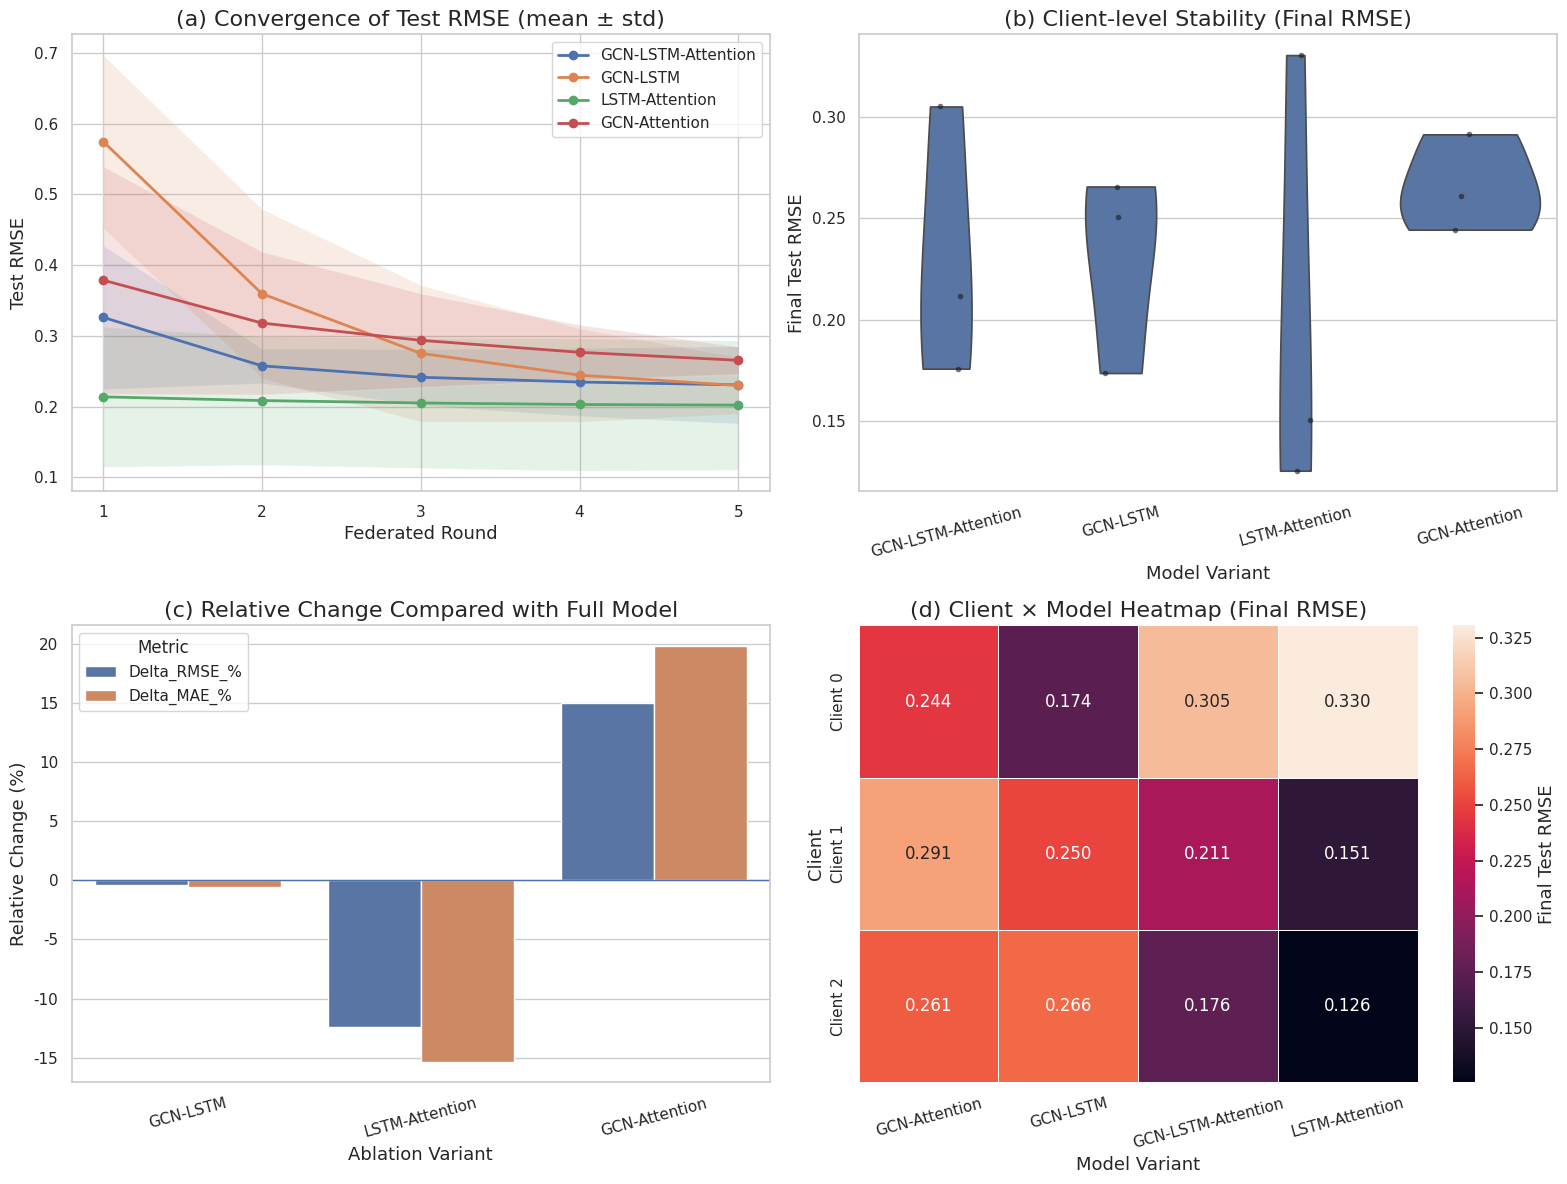


=== Final Test Metrics Summary (mean ± std across clients) ===
             Model  rmse_mean  rmse_std  mae_mean  mae_std  mse_mean  mse_std
     GCN-Attention   0.265549  0.019472  0.240463 0.018553  0.070895 0.010476
          GCN-LSTM   0.229952  0.040252  0.199475 0.035245  0.054498 0.017496
GCN-LSTM-Attention   0.230832  0.054526  0.200681 0.061306  0.056257 0.026666
    LSTM-Attention   0.202191  0.091296  0.169894 0.084209  0.049216 0.042527


In [2]:
# ============================================
# GCN + LSTM + Attention + Federated Learning
# Ablation Study (REWRITTEN)
#
# Uses the SAME dataset + FL protocol + aggregation logic as your given script
# Ablations:
#   - Full: GCN + LSTM + Attention
#   - GCN + LSTM (no Attention fusion)
#   - LSTM + Attention (no GCN)
#   - GCN + Attention (no LSTM)
#
# Outputs (paper-style 2×2):
#   (a) Round-wise convergence: Test RMSE mean ± std across clients
#   (b) Client stability: Final RMSE distribution
#   (c) Δ% vs Full (RMSE/MAE)
#   (d) Heatmap: clients × variants (final RMSE)
#
# Notes:
# - x-axis ticks are forced to integers.
# - Evaluations are done on the GLOBAL model each round.
# ============================================

import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# 0) Reproducibility + Style
# =========================
SEED = 48
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# 1) Adaptive Activation (MUST be defined before GCNEncoder uses it)
# =========================
class AdaptiveSwish(nn.Module):
    def __init__(self, trainable=True):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1, dtype=torch.float32)) if trainable else torch.tensor(1.0, dtype=torch.float32)

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# =========================
# 2) GCN Encoder (same logic as your given script)
# =========================
class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)

    def forward(self, X, A_norm):
        # X: [B, K, F], A_norm: [K, K]
        AX = torch.einsum("ij,bjf->bif", A_norm, X)
        return self.lin(AX)

class GCNEncoder(nn.Module):
    def __init__(self, K, T, hidden_dim=128):
        super().__init__()
        self.K = K
        self.T = T
        self.hidden_dim = hidden_dim

        self.node_proj = nn.Sequential(
            nn.Linear(T, hidden_dim),
            nn.LayerNorm(hidden_dim),
            AdaptiveSwish(),
        )

        self.gcn1 = SimpleGCNLayer(hidden_dim, hidden_dim)
        self.gcn2 = SimpleGCNLayer(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act = AdaptiveSwish()

        # Learnable adjacency (KxK)
        self.A_param = nn.Parameter(torch.randn(K, K) * 0.01)

    def _normalize_adj(self, A):
        A = torch.relu(A)
        I = torch.eye(self.K, device=A.device, dtype=A.dtype)
        A = A + I
        deg = A.sum(dim=1)  # [K]
        deg_inv_sqrt = torch.pow(deg + 1e-12, -0.5)
        D_inv_sqrt = torch.diag(deg_inv_sqrt)
        return D_inv_sqrt @ A @ D_inv_sqrt

    def forward(self, x):
        # x: [B, K, T]
        x = x.to(dtype=torch.float32)
        X = self.node_proj(x)  # [B,K,hidden]
        A_norm = self._normalize_adj(self.A_param)

        H = self.gcn1(X, A_norm)
        H = self.norm1(H)
        H = self.act(H)

        H = self.gcn2(H, A_norm)
        H = self.norm2(H)
        H = self.act(H)

        g = H.mean(dim=1)  # [B,hidden]
        return g

# =========================
# 3) Ablation model variants (same fusion idea as your script)
# =========================
class GCN_LSTM_Attention(nn.Module):
    """Full: GCN + LSTM + Attention fusion (2 tokens)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.gcn_encoder = GCNEncoder(K=K, T=T, hidden_dim=hidden_dim)

        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_gcn = self.gcn_encoder(x)  # [B,hidden]

        x_lstm = x.permute(0, 2, 1)  # [B,T,K]
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = x_lstm.mean(dim=1)  # [B,hidden]
        x_lstm = self.lstm_proj(x_lstm)

        feat_seq = torch.stack([x_gcn, x_lstm], dim=1)  # [B,2,hidden]
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w


class GCN_LSTM(nn.Module):
    """Ablation: GCN + LSTM (no attention fusion)"""
    def __init__(self, K, T, hidden_dim=128):
        super().__init__()
        self.gcn_encoder = GCNEncoder(K=K, T=T, hidden_dim=hidden_dim)

        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.fuse = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            AdaptiveSwish(),
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_gcn = self.gcn_encoder(x)

        x_lstm = x.permute(0, 2, 1)
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = x_lstm.mean(dim=1)
        x_lstm = self.lstm_proj(x_lstm)

        fused = self.fuse(torch.cat([x_gcn, x_lstm], dim=1))
        return self.head(fused), None


class LSTM_Attention(nn.Module):
    """Ablation: LSTM + Attention (no GCN token; 1-token self-attn)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_lstm = x.permute(0, 2, 1)
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = x_lstm.mean(dim=1)
        x_lstm = self.lstm_proj(x_lstm)

        feat_seq = x_lstm.unsqueeze(1)  # [B,1,hidden]
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w


class GCN_Attention(nn.Module):
    """Ablation: GCN + Attention (no LSTM token; 1-token self-attn)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.gcn_encoder = GCNEncoder(K=K, T=T, hidden_dim=hidden_dim)

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_gcn = self.gcn_encoder(x)

        feat_seq = x_gcn.unsqueeze(1)
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w

# =========================
# 4) Dataset (SAME generation logic as your given script)
# =========================
class HeterogeneousDataset(Dataset):
    def __init__(self, client_id, num_samples, K, T, noise=0.1):
        # keep behavior close to your original
        self.X = np.random.randn(num_samples, K, T).astype(np.float32)

        base_feature = self.X[:, :, T // 4 : T * 3 // 4].mean(axis=(1, 2))
        if client_id == 0:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.sin(self.X[:, :, : T // 2].mean(axis=(1, 2))) + noise * np.random.randn(num_samples)
        elif client_id == 1:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.cos(self.X[:, :, T // 2 :].mean(axis=(1, 2))) + noise * np.random.randn(num_samples)
        else:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.tanh(self.X.max(axis=(1, 2))) + noise * np.random.randn(num_samples)

        self.y = self.y.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# =========================
# 5) Federated client + server (SAME aggregation spirit)
# =========================
class FedClient:
    def __init__(self, client_id, model, train_loader, test_loader, criterion, lr=1e-3):
        self.client_id = client_id
        self.model = model.to(device).float()
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=3, gamma=0.9)
        self.train_losses = []
        self.val_losses = []

    def train_epoch(self):
        self.model.train()
        total_loss, n = 0.0, 0
        for x, y in self.train_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()

            self.optimizer.zero_grad()
            pred, _ = self.model(x)
            loss = self.criterion(pred.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        avg = total_loss / max(1, n)
        self.train_losses.append(avg)
        return avg

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss, n = 0.0, 0
        for x, y in self.test_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()

            pred, _ = self.model(x)
            total_loss += self.criterion(pred.squeeze(), y).item() * x.size(0)
            n += x.size(0)

        avg = total_loss / max(1, n)
        self.val_losses.append(avg)
        self.scheduler.step()
        return avg

    def train(self, epochs=5, global_model=None, verbose=False):
        if global_model is not None:
            self.model.load_state_dict(global_model.state_dict())

        last = None
        for ep in range(epochs):
            tr = self.train_epoch()
            va = self.validate()
            last = tr
            if verbose:
                print(f"  Local epoch {ep+1}/{epochs}, Train loss: {tr:.6f}, Val loss: {va:.6f}")
        return float(last), copy.deepcopy(self.model.state_dict())

    @torch.no_grad()
    def test_metrics(self):
        self.model.eval()
        preds, truths = [], []
        for x, y in self.test_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()
            pred, _ = self.model(x)
            preds.append(pred.squeeze())
            truths.append(y)
        preds = torch.cat(preds, dim=0)
        truths = torch.cat(truths, dim=0)

        diff = preds - truths
        mse = float((diff ** 2).mean().item())
        mae = float(diff.abs().mean().item())
        rmse = float(np.sqrt(mse))
        return {"mse": mse, "rmse": rmse, "mae": mae}

class Server:
    def __init__(self, model, num_clients):
        self.global_model = model.to(device).float()
        self.num_clients = num_clients
        self.round_losses = []
        self.client_data_sizes = None

    def set_client_data_sizes(self, sizes):
        self.client_data_sizes = sizes

    def aggregate(self, client_weights, client_losses):
        # same as your script: combine data-size weights + exp(-loss) weights, then momentum mix
        data_weights = np.array(self.client_data_sizes) / float(sum(self.client_data_sizes))
        loss_w = np.exp(-np.array(client_losses) * 2.0)
        loss_weights = loss_w / (loss_w.sum() + 1e-12)

        w = 0.5 * data_weights + 0.5 * loss_weights
        w = w / (w.sum() + 1e-12)

        global_dict = self.global_model.state_dict()
        new_dict = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in global_dict.items()}

        for k in new_dict.keys():
            for i in range(self.num_clients):
                cw = client_weights[i][k].to(device, dtype=torch.float32)
                new_dict[k] += cw * torch.tensor(float(w[i]), device=device, dtype=torch.float32)

        # momentum mixing
        for k in new_dict.keys():
            new_dict[k] = 0.9 * global_dict[k] + 0.1 * new_dict[k]

        self.global_model.load_state_dict(new_dict)
        self.round_losses.append(float(np.mean(client_losses)))
        return self.global_model.state_dict()

# =========================
# 6) Experiment setup (same as yours)
# =========================
num_clients = 3
K, T = 5, 24
samples_per_client = [50, 80, 120]
num_rounds = 5
local_epochs = 5
criterion = nn.MSELoss()

# deterministic split
g_split = torch.Generator().manual_seed(SEED)

def build_loaders():
    train_loaders, test_loaders = [], []
    for cid in range(num_clients):
        dataset = HeterogeneousDataset(client_id=cid, num_samples=samples_per_client[cid], K=K, T=T)
        train_size = int(0.8 * len(dataset))
        train_data, test_data = random_split(dataset, [train_size, len(dataset) - train_size], generator=g_split)

        g_loader = torch.Generator().manual_seed(SEED + cid)
        train_loader = DataLoader(train_data, batch_size=8, shuffle=True, generator=g_loader)
        test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

        train_loaders.append(train_loader)
        test_loaders.append(test_loader)
    return train_loaders, test_loaders

# =========================
# 7) Run ONE federated variant (records round-wise GLOBAL test rmse)
# =========================
def eval_global_on_clients(global_model, clients):
    # evaluate GLOBAL model on each client's test loader
    per_client = []
    for c in clients:
        c.model.load_state_dict(global_model.state_dict())
        met = c.test_metrics()
        per_client.append(met)
    return per_client

def run_federated_variant(model_ctor, variant_name, lr=1e-3, verbose=True):
    train_loaders, test_loaders = build_loaders()

    clients = [
        FedClient(cid, model_ctor(), train_loaders[cid], test_loaders[cid], criterion, lr=lr)
        for cid in range(num_clients)
    ]
    server = Server(model_ctor(), num_clients)
    server.set_client_data_sizes(samples_per_client)

    hist_train_client, hist_train_mean, hist_train_std = [], [], []
    hist_test_client,  hist_test_mean,  hist_test_std  = [], [], []

    if verbose:
        print("\n" + "=" * 50)
        print(f"Start Federated Training: {variant_name}")
        print("=" * 50)

    for rnd in range(num_rounds):
        if verbose:
            print(f"\n----- Round {rnd+1}/{num_rounds} -----")

        client_weights, client_losses = [], []

        # local train
        for c in clients:
            loss, w = c.train(epochs=local_epochs, global_model=server.global_model, verbose=False)
            client_weights.append(w)
            client_losses.append(float(loss))
            if verbose:
                print(f"Client {c.client_id} | Local avg MSE: {loss:.6f}")

        server.aggregate(client_weights, client_losses)

        # record train stats
        hist_train_client.append(client_losses)
        hist_train_mean.append(float(np.mean(client_losses)))
        hist_train_std.append(float(np.std(client_losses, ddof=0)))

        # GLOBAL test rmse across clients
        per_client_metrics = eval_global_on_clients(server.global_model, clients)
        per_client_rmse = np.array([m["rmse"] for m in per_client_metrics], dtype=float)

        hist_test_client.append(per_client_rmse.tolist())
        hist_test_mean.append(float(per_client_rmse.mean()))
        hist_test_std.append(float(per_client_rmse.std(ddof=0)))

        if verbose:
            print(f"Round {rnd+1} | Global Test RMSE mean: {hist_test_mean[-1]:.6f} (std {hist_test_std[-1]:.6f})")

    # final global -> per-client metrics
    final_list = eval_global_on_clients(server.global_model, clients)
    df_final = pd.DataFrame(final_list)
    df_final["cid"] = list(range(num_clients))
    df_final = df_final.sort_values("cid").reset_index(drop=True)

    summary = {
        "mse_mean": float(df_final["mse"].mean()),  "mse_std": float(df_final["mse"].std(ddof=0)),
        "rmse_mean": float(df_final["rmse"].mean()), "rmse_std": float(df_final["rmse"].std(ddof=0)),
        "mae_mean": float(df_final["mae"].mean()),  "mae_std": float(df_final["mae"].std(ddof=0)),
    }

    history = {
        "train_mean": hist_train_mean,
        "train_std": hist_train_std,
        "train_client": hist_train_client,
        "test_mean": hist_test_mean,
        "test_std": hist_test_std,
        "test_client": hist_test_client,
    }

    return server.global_model, df_final, summary, history

# =========================
# 8) Run ablations (using your model dimensions)
# =========================
variants = {
    "GCN-LSTM-Attention": lambda: GCN_LSTM_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
    "GCN-LSTM":          lambda: GCN_LSTM(K=K, T=T, hidden_dim=128),
    "LSTM-Attention":    lambda: LSTM_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
    "GCN-Attention":     lambda: GCN_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
}

results_client = {}
results_summary = {}
histories = {}

for name, ctor in variants.items():
    _, df_pc, summ, hist = run_federated_variant(ctor, name, lr=1e-3, verbose=True)
    results_client[name] = df_pc
    results_summary[name] = summ
    histories[name] = hist

# =========================
# 9) Build tidy dataframes for plotting
# =========================
# (A) Convergence: Test RMSE mean ± std
conv_rows = []
for name, hist in histories.items():
    for r in range(num_rounds):
        conv_rows.append(
            {
                "Model": name,
                "Round": r + 1,
                "TestRMSE_mean": hist["test_mean"][r],
                "TestRMSE_std": hist["test_std"][r],
            }
        )
df_conv = pd.DataFrame(conv_rows)

# (B) Client stability at final (rmse/mae/mse)
stab_rows = []
for name, df_pc in results_client.items():
    for _, row in df_pc.iterrows():
        stab_rows.append(
            {
                "Model": name,
                "Client": f"Client {int(row['cid'])}",
                "rmse": float(row["rmse"]),
                "mae": float(row["mae"]),
                "mse": float(row["mse"]),
            }
        )
df_stab = pd.DataFrame(stab_rows)

# (C) Delta% vs Full
full_name = "GCN-LSTM-Attention"
full = results_summary[full_name]
delta_rows = []
for name, summ in results_summary.items():
    if name == full_name:
        continue
    delta_rows.append(
        {
            "Model": name,
            "Delta_RMSE_%": (summ["rmse_mean"] - full["rmse_mean"]) / (full["rmse_mean"] + 1e-12) * 100.0,
            "Delta_MAE_%":  (summ["mae_mean"]  - full["mae_mean"])  / (full["mae_mean"]  + 1e-12) * 100.0,
        }
    )
df_delta = pd.DataFrame(delta_rows)

# (D) Heatmap: clients × models (final RMSE)
client_labels = [f"Client {i}" for i in range(num_clients)]
heat = df_stab.pivot_table(index="Client", columns="Model", values="rmse", aggfunc="mean")
heat = heat.reindex(index=client_labels)

# =========================
# 10) Visualization (2×2 paper-style) + integer x ticks
# =========================
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# (a) Convergence
for name in df_conv["Model"].unique():
    sub = df_conv[df_conv["Model"] == name].sort_values("Round")
    x = sub["Round"].to_numpy(dtype=int)
    y = sub["TestRMSE_mean"].to_numpy(dtype=float)
    s = sub["TestRMSE_std"].to_numpy(dtype=float)

    ax1.plot(x, y, marker="o", linewidth=2, label=name)
    ax1.fill_between(x, y - s, y + s, alpha=0.15)

ax1.set_xlabel("Federated Round")
ax1.set_ylabel("Test RMSE")
ax1.set_title("(a) Convergence of Test RMSE (mean ± std)")
ax1.set_xticks(np.arange(1, num_rounds + 1, dtype=int))  # integer ticks
ax1.legend(frameon=True)

# (b) Client stability (Final RMSE)
sns.violinplot(data=df_stab, x="Model", y="rmse", inner=None, cut=0, ax=ax2)
sns.stripplot(data=df_stab, x="Model", y="rmse", color="k", size=4, alpha=0.6, ax=ax2)
ax2.set_xlabel("Model Variant")
ax2.set_ylabel("Final Test RMSE")
ax2.set_title("(b) Client-level Stability (Final RMSE)")
ax2.tick_params(axis="x", rotation=15)

# (c) Relative change vs Full
if len(df_delta) > 0:
    df_delta_melt = df_delta.melt(id_vars=["Model"], var_name="Metric", value_name="DeltaPercent")
    sns.barplot(data=df_delta_melt, x="Model", y="DeltaPercent", hue="Metric", ax=ax3)
    ax3.axhline(0, linewidth=1)
    ax3.set_xlabel("Ablation Variant")
    ax3.set_ylabel("Relative Change (%)")
    ax3.set_title("(c) Relative Change Compared with Full Model")
    ax3.tick_params(axis="x", rotation=15)
    ax3.legend(title="Metric", frameon=True)
else:
    ax3.axis("off")

# (d) Heatmap: Clients × Models
sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Final Test RMSE"},
    ax=ax4,
)
ax4.set_xlabel("Model Variant")
ax4.set_ylabel("Client")
ax4.set_title("(d) Client × Model Heatmap (Final RMSE)")
ax4.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# =========================
# 11) Summary table
# =========================
df_sum = (
    pd.DataFrame(results_summary)
      .T.reset_index()
      .rename(columns={"index": "Model"})
      .sort_values("Model")
)
df_sum = df_sum[[
    "Model",
    "rmse_mean", "rmse_std",
    "mae_mean", "mae_std",
    "mse_mean", "mse_std",
]]

print("\n=== Final Test Metrics Summary (mean ± std across clients) ===")
print(df_sum.to_string(index=False))
